# Transformers

## Positional-Encoding

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  5.1514e-01,  ...,  1.0000e+00,
          1.8478e-04,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  8.8306e-01,  ...,  1.0000e+00,
          3.6957e-04,  1.0000e+00],
        ...,
        [ 3.7961e-01, -9.2515e-01,  7.9173e-01,  ...,  9.9945e-01,
          1.7923e-02,  9.9984e-01],
        [-5.7338e-01, -8.1929e-01,  3.6391e-01,  ...,  9.9944e-01,
          1.8108e-02,  9.9984e-01],
        [-9.9921e-01,  3.9821e-02, -1.6791e-01,  ...,  9.9943e-01,
          1.8293e-02,  9.9983e-01]])


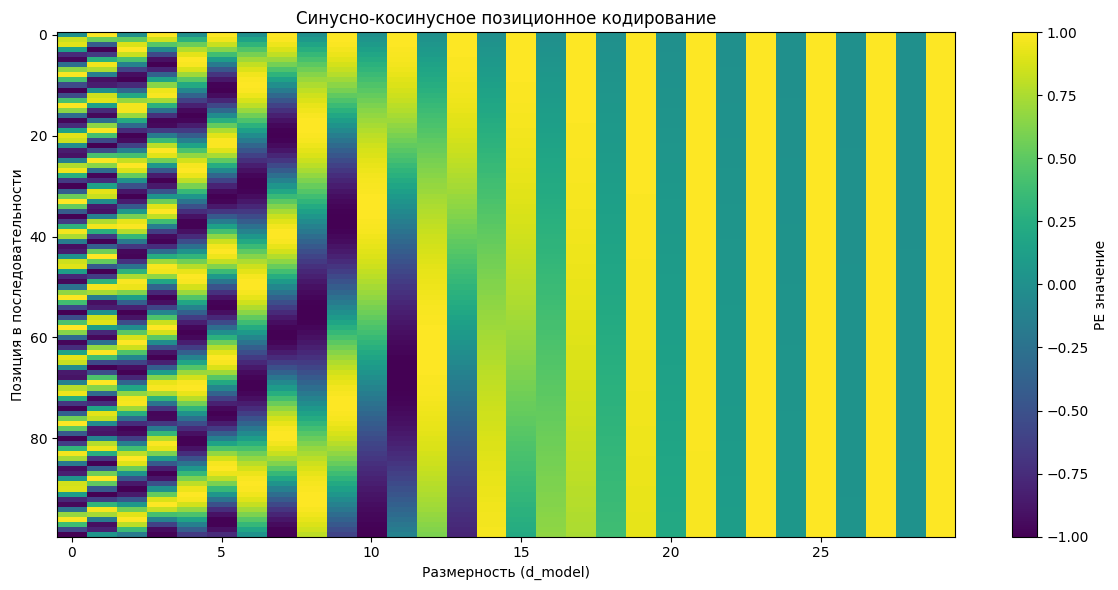

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Параметры
d_model = 30
seq_len = 100
batch_size = 2

# Синусно-косинусное позиционное кодирование
pos = torch.arange(seq_len).unsqueeze(1)  # (seq_len, 1)
i = torch.arange(0, d_model, 2)            # (d_model/2,)
angle_rates = 1 / torch.pow(10000, i / d_model)  # (d_model/2,)
pos_enc = torch.zeros(seq_len, d_model)  # (seq_len, d_model)
pos_enc[:, 0::2] = torch.sin(pos * angle_rates)  # чётные индексы
pos_enc[:, 1::2] = torch.cos(pos * angle_rates)  # нечётные индексы

print(pos_enc)

# Визуализация
plt.figure(figsize=(12, 6))
plt.imshow(pos_enc, aspect='auto', cmap='viridis')
plt.xlabel('Размерность (d_model)')
plt.ylabel('Позиция в последовательности')
plt.title('Синусно-косинусное позиционное кодирование')
plt.colorbar(label='PE значение')
plt.tight_layout()
plt.show()

## Encoder-Block

In [3]:
import torch
import torch.nn as nn

class FeedForward(nn.Module):
    def __init__(self, d_model, dim_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, dim_ff)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(dim_ff, d_model)

    def forward(self, x):
        # x shape: (seq_len, batch, d_model)
        x = self.linear1(x)   # (seq_len, batch, dim_ff)
        x = self.relu(x)
        x = self.linear2(x)   # (seq_len, batch, d_model)
        return x

# Проверим, что FeedForward не меняет форму тензора
d_model, dim_ff = 64, 256
ff_block = FeedForward(d_model, dim_ff)
seq_len, batch_size = 5, 2
x = torch.randn(seq_len, batch_size, d_model)
y = ff_block(x)
print(x.shape, '->', y.shape)  # (5, 2, 64) -> (5, 2, 64)

torch.Size([5, 2, 64]) -> torch.Size([5, 2, 64])


In [4]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, dim_ff):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dim_ff)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # x shape: (seq_len, batch_size, d_model)
        attn_out, _ = self.self_attn(x, x, x)     # Multi-Head Attention
        x = self.norm1(x + attn_out)              # Add & Norm
        ff_out = self.ff(x)                       # FeedForward
        x = self.norm2(x + ff_out)               # Add & Norm
        return x

# Пример использования блока энкодера:
d_model, num_heads, dim_ff = 64, 8, 256
encoder_block = TransformerEncoderBlock(d_model, num_heads, dim_ff)
x = torch.randn(10, 2, d_model)          # (seq_len=10, batch_size=2, d_model=64)
y = encoder_block(x)
print(y.shape)  # (10, 2, 64)

torch.Size([10, 2, 64])


## MultiHeadAttention

In [5]:
import torch
import torch.nn as nn

class MyMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model должно делиться на num_heads"
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        # Линейные слои для Q, K, V и выходной слой
        self.WQ = nn.Linear(d_model, d_model, bias=False)
        self.WK = nn.Linear(d_model, d_model, bias=False)
        self.WV = nn.Linear(d_model, d_model, bias=False)
        self.WO = nn.Linear(d_model, d_model, bias=False)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (seq_len, batch, d_model)
        seq_len, batch, d_model = query.shape

        # Проекция Q, K, V
        Q = self.WQ(query)  # (seq_len, batch, d_model)
        K = self.WK(key)
        V = self.WV(value)

        # Переставим размерности так, чтобы голова была отдельным измерением
        # Сначала делаем (batch, seq_len, d_model)
        Q = Q.permute(1, 0, 2)
        K = K.permute(1, 0, 2)
        V = V.permute(1, 0, 2)
        # Затем разбиваем по головам и снова транспонируем:
        # (batch, num_heads, seq_len, head_dim)
        Q = Q.view(batch, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch, seq_len, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        # Скалярное произведение и softmax
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)  # (batch, heads, seq, seq)
        if mask is not None:
            # Расширяем маску до (batch, heads, seq, seq) и зануляем запрещённые связи
            mask = mask.unsqueeze(0).unsqueeze(1)  # (1,1,seq,seq)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attention = torch.softmax(scores, dim=-1)  # (batch, heads, seq, seq)

        # Взвешенное суммирование значений
        out = torch.matmul(attention, V)  # (batch, heads, seq, head_dim)

        # Объединяем головы обратно: (batch, seq_len, d_model)
        out = out.permute(0, 2, 1, 3).contiguous().view(batch, seq_len, d_model)
        # Финальный линейный слой
        out = self.WO(out)  # (batch, seq_len, d_model)
        # Возвращаем в формат (seq_len, batch, d_model)
        out = out.permute(1, 0, 2)
        return out

# Использование класса MyMultiHeadAttention:
d_model, num_heads = 64, 8
mha = MyMultiHeadAttention(d_model, num_heads)
x = torch.randn(10, 2, d_model)    # (seq_len=10, batch=2, d_model=64)
y = mha(x, x, x, mask=None)
print(y.shape)  # (10, 2, 64)

torch.Size([10, 2, 64])


# BERT

In [6]:
from transformers import BertTokenizer, BertForMaskedLM
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForMaskedLM.from_pretrained('bert-base-uncased')

sentence = "Paris is the capital of [MASK]."
inputs = tokenizer(sentence, return_tensors="pt")
# Используйте позицию [MASK] и получите предсказание
mask_index = torch.where(inputs["input_ids"][0] == tokenizer.mask_token_id)[0].item()

# Выполните предсказание и получите логиты
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# Выберите токен с наивысшим логитом в позиции маски с помощью argmax и item
predicted_index = logits[0, mask_index].argmax().item()
print(tokenizer.decode(predicted_index))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


france


In [7]:
import torch
from transformers import BertTokenizer, BertForNextSentencePrediction

# Инициализация модели и токенизатора
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForNextSentencePrediction.from_pretrained('bert-base-uncased')

# Пример для IsNext (последовательные предложения)
text_a = "The cat sat on the mat."
text_b = "It was very sleepy."

# Токенизация и подготовка входа
inputs = tokenizer(text_a, text_b, return_tensors='pt')

# Получение предсказаний
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# Интерпретация результатов
is_next_prob = torch.softmax(logits, dim=1)[0][1].item()  # Вероятность NotNext
not_next_prob = torch.softmax(logits, dim=1)[0][0].item() # Вероятность IsNext

print(f"Вероятность IsNext: {not_next_prob:.4f}")
print(f"Вероятность NotNext: {is_next_prob:.4f}")
print("\n" + "="*80 + "\n")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForNextSentencePrediction LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Вероятность IsNext: 1.0000
Вероятность NotNext: 0.0000




In [8]:
# Пример для NotNext (непоследовательные предложения)
text_a = "The cat sat on the mat."
text_b = "The Eiffel Tower is located in Paris."

# Токенизация и подготовка входа
inputs = tokenizer(text_a, text_b, return_tensors='pt')

# Получение предсказаний
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

# Интерпретация результатов
is_next_prob = torch.softmax(logits, dim=1)[0][1].item()  # Вероятность NotNext
not_next_prob = torch.softmax(logits, dim=1)[0][0].item() # Вероятность IsNext

print(f"Вероятность IsNext: {not_next_prob:.4f}")
print(f"Вероятность NotNext: {is_next_prob:.4f}")
print("\n" + "="*80 + "\n")

Вероятность IsNext: 0.0001
Вероятность NotNext: 0.9999




# Профилирование GPU

In [9]:
from transformers import BertForSequenceClassification


model = BertForSequenceClassification.from_pretrained('bert-base-uncased').cuda()

assert torch.cuda.is_available(), "Ошибка: GPU недоступна!"

for seq_len in [128,256,512]:
    x = torch.randint(0, model.config.vocab_size, (1, seq_len)).cuda()
    torch.cuda.reset_peak_memory_stats()
    _ = model(x)
    print(f"Длина {seq_len}: пиковое потребление ≈ {torch.cuda.max_memory_allocated()/1024**2:.0f} МБ")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Длина 128: пиковое потребление ≈ 510 МБ
Длина 256: пиковое потребление ≈ 657 МБ
Длина 512: пиковое потребление ≈ 884 МБ


# Оптимизация внимания

In [10]:
import torch, torch.nn.functional as F

def sliding_window_attention(Q, K, V, window_size):
    # Q,K,V формы (seq_len, batch, d_model)
    seq_len = Q.size(0)
    # Создаём маску формата (seq_len, seq_len) с -inf для запрещённых связей
    mask = torch.full((seq_len, seq_len), float('-inf'))
    for i in range(seq_len):
        left = max(0, i - window_size)
        right = min(seq_len, i + window_size + 1)
        mask[i, left:right] = 0
    # Переставляем размерности, чтобы батч был первым
    Q, K, V = Q.transpose(0, 1), K.transpose(0, 1), V.transpose(0, 1) # shape: (batch, seq_len, d_model)
    # Изменяем размер маски для соответствия батч размеру Q (shape: [batch, seq_len, seq_len])
    mask = mask.unsqueeze(0).expand(Q.size(0), -1, -1)
    # Используем scaled_dot_product_attention с маской
    attn_out = F.scaled_dot_product_attention(Q, K, V, attn_mask=mask)
    # Возвращаем результат обратно в исходном порядке: (seq_len, batch, d_model)
    attn_out = attn_out.transpose(0, 1)
    return attn_out, mask

# Проверка маскированного внимания:
seq_len, batch, d_model = 10, 2, 16
Q = torch.randn(seq_len, batch, d_model)
out, mask = sliding_window_attention(Q, Q, Q, window_size=2)
print(out.shape)

# Дополнительная проверка визуализацией
print("\nПример маски для позиции 5 (первый батч):")
print(mask[0, 5].detach().numpy().round(1))

torch.Size([10, 2, 16])

Пример маски для позиции 5 (первый батч):
[-inf -inf -inf   0.   0.   0.   0.   0. -inf -inf]


In [11]:
import torch, torch.nn.functional as F
from torch.nn.attention import SDPBackend, sdpa_kernel

# Параметры теста
batch, heads, seq_len, head_dim = 8, 4, 512, 32
dtype = torch.float16
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Случайные Q,K,V
query = torch.randn(batch, heads, seq_len, head_dim, device=device, dtype=dtype)
key   = torch.randn_like(query)
value = torch.randn_like(query)

# Функция для бенчмарка (в мкс)
import torch.utils.benchmark as benchmark
def bench(f, *args):
    t0 = benchmark.Timer(stmt="f(*args)", globals={"f": f, "args": args})
    return t0.blocked_autorange().mean * 1e6

print("Тестовый запуск...")

# Обычная реализация (Math)
with sdpa_kernel(SDPBackend.MATH):
    t_math = bench(F.scaled_dot_product_attention, query, key, value)
print(f"Math implementation: {t_math:.1f} мкс")

# Flash Attention реализация
with sdpa_kernel(SDPBackend.FLASH_ATTENTION):
    try:
        t_flash = bench(F.scaled_dot_product_attention, query, key, value)
        print(f"Flash Attention impl.: {t_flash:.1f} мкс")
    except RuntimeError as e:
        print("Flash Attention не поддерживается:", e)

# Память-эффективная реализация
with sdpa_kernel(SDPBackend.EFFICIENT_ATTENTION):
    t_eff = bench(F.scaled_dot_product_attention, query, key, value)
print(f"Memory-Efficient impl.: {t_eff:.1f} мкс")

Тестовый запуск...
Math implementation: 447.4 мкс
Flash Attention impl.: 22.6 мкс
Memory-Efficient impl.: 68.3 мкс


# Tokenizers

## Byte-Pair Encoding (BPE)

In [1]:
from collections import Counter

def get_pairs(symbols):
    """
    Возвращает список кортежей соседних пар в списке символов.
    Пример: ["h","e","l","l","o"] -> 
    [("h","e"),("e","l"),("l","l"),("l","o")].
    """
    pairs = []
    for i in range(len(symbols)-1):
        pairs.append((symbols[i], symbols[i+1]))
    return pairs


def best_pair(words):
    """
    Находит пару (bigram), которую нужно слить на следующем шаге BPE:
    выбирает самую частотную соседнюю пару по всем словам.

    words: список слов, где каждое слово — список символов/токенов.
           например: [["a","b","a","b","c"], ["a","b","c"]]
    Возвращает: (пара, частота) или (None, 0), если пар нет.
    """
    pair_counts = Counter()

    for symbols in words:
        pair_counts.update(get_pairs(symbols))

    if not pair_counts:
        return None, 0

    pair, freq = pair_counts.most_common(1)[0]
    return pair, freq


def merge_pair(symbols, pair):
    """
    Объединяет все вхождения заданной пары в новый токен.
    Пример: ["h","e","l","l","o"], pair=("l","l") 
    -> ["h","e","ll","o"].
    """
    new_symbols = []
    i = 0
    while i < len(symbols):
        # Если найдено вхождение пары, объединяем её
        if i < len(symbols)-1 and (symbols[i], symbols[i+1]) == pair:
            new_symbols.append(symbols[i] + symbols[i+1])
            i += 2
        else:
            new_symbols.append(symbols[i])
            i += 1
    return new_symbols

words = [
    ["a", "b", "c", "a"],
    ["a", "b", "c"],
    ["b", "c", "a"]
]

pair, freq = best_pair(words)
print(pair, freq)

words_merged = [merge_pair(w, pair) for w in words]
print(words_merged)

('b', 'c') 3
[['a', 'bc', 'a'], ['a', 'bc'], ['bc', 'a']]


## WordPiece

In [2]:
from collections import Counter

def wp_strip(tok: str) -> str:
    """Убирает префикс ## если он есть."""
    return tok[2:] if tok.startswith("##") else tok

def wp_prefix(tok: str) -> str:
    """Если токен продолжения слова — возвращаем '##', иначе ''."""
    return "##" if tok.startswith("##") else ""

def get_pairs_wp(symbols):
    """
    Соседние пары как в BPE.
    Пример: ["h","##e","##l"] -> [("h","##e"),("##e","##l")]
    """
    pairs = []
    for i in range(len(symbols) - 1):
        pairs.append((symbols[i], symbols[i+1]))
    return pairs

def merge_pair_wp(symbols, pair):
    """
    Объединяет все вхождения пары в новый WordPiece-токен,
    корректно обрабатывая '##'.

    Правило:
    - если первый токен пары начинается с '##', то и результат начинается с '##'
    - при склейке удаляем '##' у обоих частей и склеиваем "чистые" строки
    """
    a, b = pair
    new_symbols = []
    i = 0
    while i < len(symbols):
        if i < len(symbols) - 1 and (symbols[i], symbols[i+1]) == pair:
            pref = wp_prefix(symbols[i])
            merged = pref + wp_strip(symbols[i]) + wp_strip(symbols[i+1])
            new_symbols.append(merged)
            i += 2
        else:
            new_symbols.append(symbols[i])
            i += 1
    return new_symbols

def best_pair_wp(words):
    """
    Выбирает пару для слияния по скору WordPiece:
        score(a,b) = count(a b) / (count(a) * count(b))

    words: список слов, где слово — список wp-токенов (с ## для продолжений)
    Возвращает: (pair, score, pair_freq) или (None, 0.0, 0)
    """
    token_counts = Counter()
    pair_counts = Counter()

    for symbols in words:
        token_counts.update(symbols)
        pair_counts.update(get_pairs_wp(symbols))

    if not pair_counts:
        return None, 0.0, 0

    best_pair = None
    best_score = -1.0
    best_freq = 0

    for (a, b), freq in pair_counts.items():
        score = freq / (token_counts[a] * token_counts[b])
        if score > best_score or (score == best_score and freq > best_freq):
            best_score = score
            best_pair = (a, b)
            best_freq = freq

    return best_pair, best_score, best_freq

def init_wordpiece_tokens(word: str):
    if not word:
        return []
    return [word[0]] + [f"##{ch}" for ch in word[1:]]

words = [
    init_wordpiece_tokens("abab"),
    init_wordpiece_tokens("abac"),
    init_wordpiece_tokens("ab"),
]
print(words)

pair, score, freq = best_pair_wp(words)
print("best:", pair, "score:", score, "freq:", freq)

words2 = [merge_pair_wp(w, pair) for w in words]
print(words2)

[['a', '##b', '##a', '##b'], ['a', '##b', '##a', '##c'], ['a', '##b']]
best: ('##a', '##c') score: 0.5 freq: 1
[['a', '##b', '##a', '##b'], ['a', '##b', '##ac'], ['a', '##b']]


# RoBERTa/DeBERTa

In [4]:
pip install sentencepiece protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.5 MB/s eta 0:00:00? eta -:--:--

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import pipeline
import torch

# Загружаем токенизатор и модель XLM-R для классификации тональности
model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Создаём pipeline для классификации
classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

# Тестовые тексты на разных языках
texts = [
    "This movie is absolutely fantastic! I loved every moment of it.",  # английский
    "Этот фильм просто ужасен, потратил время зря.",  # русский  
    "¡Me encanta este producto! Es increíble y muy útil.",  # испанский
    "I'm not sure about this book, it's okay I guess.",  # английский
    "Сервис отличный, всем рекомендую!",  # русский
    "No me gusta nada, muy decepcionante."  # испанский
]

# Классифицируем тональность для каждого текста
for i, text in enumerate(texts):
    result = classifier(text)
    print(f"Текст {i+1}: {text}")
    print(f"Тональность: {result[0]['label']} (уверенность: {result[0]['score']:.3f})")
    print("-" * 50)

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Загружаем токенизатор и модель DeBERTa, дообученную для NLI / fact-checking
model_name = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

# Сложные пары предложений для анализа с переводами
pairs = [
    {
        "premise_en": "The bank by the river was steep and muddy.",
        "hypothesis_en": "The financial institution was near the water.",
        "premise_ru": "Берег у реки был крутым и грязным.",
        "hypothesis_ru": "Финансовое учреждение было рядом с водой."
    },
    {
        "premise_en": "The doctor advised the lawyer because she felt unwell.",
        "hypothesis_en": "The lawyer was feeling unwell.",
        "premise_ru": "Доктор дал совет адвокату, потому что она плохо себя чувствовала.",
        "hypothesis_ru": "Адвокат плохо себя чувствовал."
    },
    {
        "premise_en": "Despite initial promising results announced in the press conference, the drug failed in clinical trials because of unexpected side effects observed in elderly patients.",
        "hypothesis_en": "Side effects caused the drug to fail.",
        "premise_ru": "Несмотря на первоначальные многообещающие результаты, объявленные на пресс-конференции, препарат провалился в клинических испытаниях из-за неожиданных побочных эффектов, наблюдаемых у пожилых пациентов.",
        "hypothesis_ru": "Побочные эффекты стали причиной провала препарата."
    }
]

# Классифицируем отношения
for pair in pairs:
    inputs = tokenizer(
        pair['premise_en'],
        pair['hypothesis_en'],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = F.softmax(outputs.logits, dim=-1)
    probs = probs[0].cpu().numpy()
    
    labels_ru = ["следствие", "нейтрально", "противоречие"]
    pred_label_ru = labels_ru[probs.argmax()]
    
    print(f"Событие: {pair['premise_ru']}")
    print(f"Гипотеза: {pair['hypothesis_ru']}")
    print(f"Предсказание: {pred_label_ru} (уверенность: {probs.max():.2%})")
    print(f"Вероятности: [следствие: {probs[0]:.2%}, нейтрально: {probs[1]:.2%}, противоречие: {probs[2]:.2%}]")
    print("-" * 80)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Событие: Берег у реки был крутым и грязным.
Гипотеза: Финансовое учреждение было рядом с водой.
Предсказание: нейтрально (уверенность: 99.85%)
Вероятности: [следствие: 0.10%, нейтрально: 99.85%, противоречие: 0.05%]
--------------------------------------------------------------------------------
Событие: Доктор дал совет адвокату, потому что она плохо себя чувствовала.
Гипотеза: Адвокат плохо себя чувствовал.
Предсказание: следствие (уверенность: 98.68%)
Вероятности: [следствие: 98.68%, нейтрально: 1.23%, противоречие: 0.10%]
--------------------------------------------------------------------------------
Событие: Несмотря на первоначальные многообещающие результаты, объявленные на пресс-конференции, препарат провалился в клинических испытаниях из-за неожиданных побочных эффектов, наблюдаемых у пожилых пациентов.
Гипотеза: Побочные эффекты стали причиной провала препарата.
Предсказание: следствие (уверенность: 98.83%)
Вероятности: [следствие: 98.83%, нейтрально: 1.04%, противоречие: 0.

# Размер модели

In [3]:
import torch
from transformers import AutoTokenizer, AutoModel

def get_model_size_mb(model):
    # Считаем размер всех параметров модели
    param_size = 0
    for param in model.parameters():
        # Количество элементов * размер каждого элемента
        param_size += param.nelement() * param.element_size()
    
    # Считаем размер буферов модели (например, batch norm statistics)
    buffer_size = 0
    for buffer in model.buffers():
        # Аналогично параметрам
        buffer_size += buffer.nelement() * buffer.element_size()
    
    # Переводим из байт в мегабайты
    # (param_size + buffer_size) делить на 1024 дважды
    total_size_mb = param_size + buffer_size
    return total_size_mb

# Тестируем функцию на разных моделях
models_to_test = [
    "distilbert-base-uncased",
    "cointegrated/rubert-tiny",
    "microsoft/MiniLM-L12-H384-uncased"
]

print("Сравнение размеров моделей")
print("=" * 40)

for model_name in models_to_test:
    print(f"\nЗагружаем {model_name}...")
    
    # Загружаем модель
    model = AutoModel.from_pretrained(model_name)
    
    # Вычисляем размер
    size_mb = get_model_size_mb(model)
    
    # Считаем количество параметров
    # Сумма всех параметров модели в миллионах
    num_params = sum(p.numel() for p in model.parameters())
    
    print(f"Размер: {size_mb:.1f} МБ")
    print(f"Параметры: {num_params:.1f}")
    print("-" * 40)

Сравнение размеров моделей

Загружаем distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Размер: 265455616.0 МБ
Параметры: 66362880.0
----------------------------------------

Загружаем cointegrated/rubert-tiny...


config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Размер: 133448192.0 МБ
Параметры: 33360000.0
----------------------------------------


model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

# Скорость работы модели

In [4]:
import time
from transformers import pipeline

def measure_inference_time(classifier, texts, num_runs=10):
    times = []
    for _ in range(num_runs):
        start_time = time.time()
        # Прогоняем все тексты через классификатор
        for text in texts:
            _ = classifier(text)
        end_time = time.time()
        # Сохраняем время выполнения
        times.append(end_time - start_time)
    
    avg_time = sum(times) / len(times)
    # Среднее время на один текст
    avg_time_per_text = avg_time / len(texts)
    return avg_time_per_text * 1000  # в миллисекундах

# Тестовые тексты на английском
test_texts = [
    "This product is amazing!", # Этот продукт потрясающий!
    "Terrible quality, very disappointed.", # Ужасное качество, очень разочарован.
    "The service was okay, nothing special.", # Сервис был нормальным, ничего особенного.
    "Outstanding experience! Highly recommend!", # Выдающийся опыт! Настоятельно рекомендую!
    "Poor customer support, took forever." # Плохая поддержка клиентов, всё заняло вечность.
]

# Список англоязычных моделей для тестирования
models_to_test = [
    "distilbert-base-uncased",
    "microsoft/MiniLM-L12-H384-uncased"
]

for model_name in models_to_test:
    print(f"\nТестирование скорости: {model_name}")
    print("=" * 50)
    
    # Создаём pipeline для модели
    classifier = pipeline("text-classification", model=model_name)
    
    # Измеряем среднее время инференса
    avg_time = measure_inference_time(classifier, test_texts)
    
    print(f"Среднее время обработки одного текста: {avg_time:.3f} мс")


Тестирование скорости: distilbert-base-uncased


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: microsoft/MiniLM-L12-H384-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Среднее время обработки одного текста: 2.713 мс


# NER на SPAN

In [6]:
import nltk
from typing import List, Tuple

# Если выдаёт ошибку, выполните:
nltk.download('punkt')
nltk.download('punkt_tab')

def tokenize_with_offsets(text: str) -> List[Tuple[str, int, int]]:
    """
    Токенизирует текст и возвращает список кортежей (token, start_char, end_char).
    """
    tokens = nltk.word_tokenize(text)
    
    offsets = []
    pos = 0  # с какой позиции искать следующий токен
    
    for tok in tokens:
        # Найти начальную позицию токена в тексте, начиная с позиции pos
        # Используйте метод text.find(tok, pos)
        start = text.find(tok, pos)
        
        # Вычислить конечную позицию (начало + длина токена)
        end = start + len(tok)
        
        # Добавить кортеж (токен, начало, конец) в список результатов
        offsets.append((tok, start, end))
        
        # Обновить позицию для поиска следующего токена
        # Следующий токен будем искать после текущего
        pos = end
    
    return offsets

# Тест
test_text = "Иван Петров работает."
result = tokenize_with_offsets(test_text)

print("Результат:")
for token, start, end in result:
    print(f"'{token}' -> [{start}-{end})")

Результат:
'Иван' -> [0-4)
'Петров' -> [5-11)
'работает' -> [12-20)
'.' -> [20-21)


[nltk_data] Downloading package punkt to /home/evgeniy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/evgeniy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [7]:
from typing import List, Tuple

def spans_to_bio(tokens_off: List[Tuple[str, int, int]], 
                 spans: List[Tuple[int, int, str]]) -> List[str]:
    """
    Преобразует спаны именованных сущностей в BIO-метки для токенов.
    """
    # Инициализируем все метки как 'O' (Outside)
    bio = ['O'] * len(tokens_off)
    
    # Обрабатываем каждый спан сущности
    for span_start, span_end, label in spans:
        first_token_in_span = True  # флаг для отслеживания первого токена в спане
        
        # Проверяем каждый токен на пересечение с текущим спаном
        for i, (token, t_start, t_end) in enumerate(tokens_off):
            
            # Проверяем, пересекается ли токен со спаном
            # Условие НЕпересечения: токен полностью до спана ИЛИ полностью после спана
            if t_end <= span_start or t_start >= span_end:
                continue  # токен не пересекается со спаном, переходим к следующему
                
            # Токен пересекается со спаном!
            if first_token_in_span:
                # Это первый токен в данном спане - помечаем как B-LABEL
                bio[i] = f"B-{label}"
                first_token_in_span = False
            else:
                # Это НЕ первый токен в спане - помечаем как I-LABEL
                bio[i] = f"I-{label}"
    
    return bio

# Простой тест
# Сначала нужна функция tokenize_with_offsets из предыдущего задания
def tokenize_with_offsets(text: str) -> List[Tuple[str, int, int]]:
    import nltk
    tokens = nltk.word_tokenize(text)
    offsets = []
    pos = 0
    for tok in tokens:
        start = text.find(tok, pos)
        end = start + len(tok)
        offsets.append((tok, start, end))
        pos = end
    return offsets

# Тест
text = "Иван Иванов работает в Яндексе."
spans = [(0, 11, "PER"), (23, 29, "ORG")]  # "Иван Иванов" и "Яндекс"

tokens_off = tokenize_with_offsets(text)
bio_tags = spans_to_bio(tokens_off, spans)

print("Результат BIO-разметки:")
for (token, start, end), bio_tag in zip(tokens_off, bio_tags):
    print(f"{token:12} -> {bio_tag}")

Результат BIO-разметки:
Иван         -> B-PER
Иванов       -> I-PER
работает     -> O
в            -> O
Яндексе      -> B-ORG
.            -> O


In [8]:
from typing import List

def bio_to_bioes(bio: List[str]) -> List[str]:
    """
    Преобразует BIO-метки в BIOES-метки.
    Параметры:
    - bio: список BIO-меток (строки вида 'B-LABEL', 'I-LABEL', 'O')
    Возвращает:
    - Список BIOES-меток (строки вида 'B-LABEL', 'I-LABEL', 'E-LABEL', 'S-LABEL', 'O')
    """
    
    bioes = []
    n = len(bio)
    
    for i, tag in enumerate(bio):
        if tag == 'O':
            # O-теги остаются без изменений
            bioes.append('O')
            continue
            
        # Разбираем тег на префикс (B/I) и лейбл (PER/ORG/LOC/...)
        # Используйте метод split с параметром maxsplit=1 для корректной обработки 
        # лейблов, содержащих дефис (например, 'B-PERSON-NAME')
        prefix, label = tag.split('-', 1)
        
        if prefix == 'B':
            # B-тег: проверяем, что идёт после него
            
            # Проверяем условия:
            # 1. Есть ли следующий элемент в списке (i+1 < n)
            # 2. Является ли следующий элемент продолжением той же сущности (I-{label})
            if i + 1 < n and bio[i + 1] == f'I-{label}':
                # После B идёт I того же лейбла → это начало многотокенной сущности
                bioes.append(f'B-{label}')
            else:
                # После B НЕ идёт I того же лейбла → это однотокенная сущность
                bioes.append(f'S-{label}')
                
        elif prefix == 'I':
            # I-тег: проверяем, что идёт после него
            
            # Аналогично проверяем следующий элемент
            if i + 1 < n and bio[i + 1] == f'I-{label}':
                # После I идёт ещё I того же лейбла → это середина многотокенной сущности  
                bioes.append(f'I-{label}')
            else:
                # После I НЕ идёт I того же лейбла → это конец многотокенной сущности
                bioes.append(f'E-{label}')
        else:
            # Неожиданный префикс (не B и не I) - оставляем как есть
            bioes.append(tag)
    
    return bioes

# Тест всех функций вместе
def tokenize_with_offsets(text: str) -> List[Tuple[str, int, int]]:
    import nltk
    tokens = nltk.word_tokenize(text)
    offsets = []
    pos = 0
    for tok in tokens:
        start = text.find(tok, pos)
        end = start + len(tok)
        offsets.append((tok, start, end))
        pos = end
    return offsets

def spans_to_bio(tokens_off, spans):
    bio = ['O'] * len(tokens_off)
    for span_start, span_end, label in spans:
        first_token_in_span = True
        for i, (token, t_start, t_end) in enumerate(tokens_off):
            if t_end <= span_start or t_start >= span_end:
                continue
            if first_token_in_span:
                bio[i] = f'B-{label}'
                first_token_in_span = False
            else:
                bio[i] = f'I-{label}'
    return bio

# Полный тест
text = "Иван Иванович Петров работает в Яндексе."
spans = [(0, 20, "PER"), (31, 37, "ORG")]  # длинная персона и короткая организация

tokens_off = tokenize_with_offsets(text)
bio_tags = spans_to_bio(tokens_off, spans)
bioes_tags = bio_to_bioes(bio_tags)

print("Сравнение BIO и BIOES:")
for (token, _, _), bio_tag, bioes_tag in zip(tokens_off, bio_tags, bioes_tags):
    print(f"{token:12} {bio_tag:8} -> {bioes_tag:8}")

Сравнение BIO и BIOES:
Иван         B-PER    -> B-PER   
Иванович     I-PER    -> I-PER   
Петров       I-PER    -> E-PER   
работает     O        -> O       
в            O        -> O       
Яндексе      B-ORG    -> S-ORG   
.            O        -> O       


In [11]:
raw_ner = [
    {'word': 'Газ', 'entity': 'B-ORG', 'score': 0.95, 'start': 10, 'end': 13},
    {'word': '##проме', 'entity': 'I-ORG', 'score': 0.93, 'start': 13, 'end': 18},
    {'word': '-', 'entity': 'O', 'score': 0.00, 'start': 18, 'end': 19},
    {'word': 'он', 'entity': 'O', 'score': 0.00, 'start': 20, 'end': 22}
]

merged = []
for res in raw_ner:
    word = res['word']
    if word.startswith('##'):
        merged[-1]['word'] += word[2:]
        merged[-1]['end'] = res['end']
    else:
        merged.append({'word': word, 'entity': res['entity'], 'start': res['start'], 'end': res['end']})
print(merged)

[{'word': 'Газпроме', 'entity': 'B-ORG', 'start': 10, 'end': 18}, {'word': '-', 'entity': 'O', 'start': 18, 'end': 19}, {'word': 'он', 'entity': 'O', 'start': 20, 'end': 22}]


In [12]:
from transformers import pipeline

def merge_entities(ner_results):
    entities = []
    current = None
    for res in ner_results:
        word = res['word']
        label = res['entity']  # B-PER, I-PER, O и т.д.
        # Удаляем префикс 'B-', 'I-', 'S-', 'E-' чтобы получить тип
        ent_type = label.split('-')[-1] if label != 'O' else None

        if word.startswith('##'):  # subword-токен
            word = word[2:]
            # Добавляем к последнему слову
            if entities:
                entities[-1]['word'] += word
                entities[-1]['end'] = res['end']
            continue

        if label.startswith('B-') or label.startswith('S-'):
            # Начинается новая сущность (или единичная)
            entities.append({'word': word, 'type': ent_type, 'start': res['start'], 'end': res['end']})
        elif label.startswith('I-') or label.startswith('E-'):
            # Продолжаем предыдущую сущность
            if entities and entities[-1]['type'] == ent_type:
                entities[-1]['word'] += ' ' + word
                entities[-1]['end'] = res['end']
            else:
                # Неожиданный случай - просто создаём новый
                entities.append({'word': word, 'type': ent_type, 'start': res['start'], 'end': res['end']})
        # Если 'O' - ничего не делаем
    return entities

ner_pipeline = pipeline("ner", model="nesemenpolkov/msu-wiki-ner", tokenizer="nesemenpolkov/msu-wiki-ner")
sentence = "Иван Иванович Иванов работает в Газпроме."
raw_results = ner_pipeline(sentence)
print(raw_results)
merged = merge_entities(raw_results)
print("Склеенные сущности:", merged)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/709M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

[{'entity': 'B-PER', 'score': np.float32(0.99934477), 'index': 1, 'word': 'Иван', 'start': 0, 'end': 4}, {'entity': 'I-PER', 'score': np.float32(0.9998091), 'index': 2, 'word': 'Иванович', 'start': 5, 'end': 13}, {'entity': 'I-PER', 'score': np.float32(0.9998066), 'index': 3, 'word': 'Иванов', 'start': 14, 'end': 20}, {'entity': 'B-ORG', 'score': np.float32(0.9987931), 'index': 6, 'word': 'Г', 'start': 32, 'end': 33}, {'entity': 'I-ORG', 'score': np.float32(0.9985285), 'index': 7, 'word': '##аз', 'start': 33, 'end': 35}, {'entity': 'I-ORG', 'score': np.float32(0.9987846), 'index': 8, 'word': '##про', 'start': 35, 'end': 38}, {'entity': 'I-ORG', 'score': np.float32(0.99886453), 'index': 9, 'word': '##ме', 'start': 38, 'end': 40}]
Склеенные сущности: [{'word': 'Иван Иванович Иванов', 'type': 'PER', 'start': 0, 'end': 20}, {'word': 'Газпроме', 'type': 'ORG', 'start': 32, 'end': 40}]


# Визуализация Attention

In [19]:
from transformers import AutoTokenizer, AutoModel
from bertviz import head_view

model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

sentence = "Иван Иванович Иванов работает в Газпроме."
inputs = tokenizer.encode(sentence, return_tensors='pt')
outputs = model(inputs)
attention = outputs.attentions  # список матриц внимания по слоям

# Покажем head-view для слоя 0, голова 0 (пример)
head_view(attention, tokenizer.convert_ids_to_tokens(inputs[0]), layer=0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<IPython.core.display.Javascript object>

In [25]:
from transformers import AutoModel
from bertviz import head_view
import torch

# Модель для анализа attention (без головы классификации)
attention_model = AutoModel.from_pretrained("cointegrated/rubert-tiny2", output_attentions=True)
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

def analyze_attention(sentence, layer=0):
    """Анализирует attention для заданного предложения"""
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    print(f"Анализируем предложение: {sentence}")
    print(f"Токены: {tokens}")
    
    with torch.no_grad():
        # Получите outputs
        outputs = attention_model(**inputs)
        # Получите attentions из outputs
        attentions = outputs.attentions
    
    print(f"Количество слоёв: {len(attentions)}")    
    # Визуализация конкретной головы
    head_view(attentions, tokens, layer=layer)

    
example_sentence = "Иван Петров работает в Google."
analyze_attention(example_sentence, layer=0)
example_sentence = "Иван Иванович Иванов работает в Газпроме."
analyze_attention(example_sentence, layer=0)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Анализируем предложение: Иван Петров работает в Google.
Токены: ['[CLS]', 'Иван', 'Петров', 'работает', 'в', 'Google', '.', '[SEP]']
Количество слоёв: 3


<IPython.core.display.Javascript object>

Анализируем предложение: Иван Иванович Иванов работает в Газпроме.
Токены: ['[CLS]', 'Иван', 'Иванович', 'Иванов', 'работает', 'в', 'Газпром', '##е', '.', '[SEP]']
Количество слоёв: 3


<IPython.core.display.Javascript object>

# Смешанная точность

In [1]:
from transformers import AutoTokenizer
from datasets import load_dataset
from transformers import DataCollatorWithPadding
from transformers import AutoModelForSequenceClassification

ds = load_dataset('zloelias/lenta-ru', split="train[:10%]")
model_name = 'sergeyzh/rubert-tiny-turbo'

tokenizer = AutoTokenizer.from_pretrained(model_name)
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_dataset = ds.map(preprocess_function, batched=True, 
                            remove_columns=['title', 'text', 'topic'])
data_collator = DataCollatorWithPadding(tokenizer, max_length=512, padding=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name, 
                                                           num_labels=5, 
                                                           device_map='auto')

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sergeyzh/rubert-tiny-turbo
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [4]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
# Импорты для AMP
from torch.amp import GradScaler, autocast

num_epochs = 5
batch_size = 1
learning_rate = 5e-5

train_dataloader = DataLoader(
    tokenized_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Инициализируем GradScaler для масштабирования градиентов
scaler = GradScaler()

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    n_batches = 0
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}"):
        # Переносим тензоры на device
        batch = {k: v.to(model.device) for k, v in batch.items()}
        
        optimizer.zero_grad()
        
        # Используем autocast для автоматического приведения к float16
        with autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(**batch)
            loss = outputs.loss
        
        # Масштабируем loss и выполняем backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")

Epoch 1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18597/18597 [02:44<00:00, 113.13it/s]


Epoch 1 avg loss: 0.1269


Epoch 2: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18597/18597 [02:44<00:00, 113.13it/s]


Epoch 2 avg loss: 0.0666


Epoch 3: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18597/18597 [02:45<00:00, 112.36it/s]


Epoch 3 avg loss: 0.0304


Epoch 4: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18597/18597 [02:44<00:00, 113.34it/s]


Epoch 4 avg loss: 0.0153


Epoch 5: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18597/18597 [02:42<00:00, 114.30it/s]

Epoch 5 avg loss: 0.0126


In [2]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

num_epochs = 5
batch_size = 8  # Реальный batch size
learning_rate = 5e-5
accumulation_steps = 4  # Эффективный batch size = 16 * 4 = 64

train_dataloader = DataLoader(
    tokenized_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    n_batches = 0
    
    # Обнуляем градиенты в начале эпохи
    optimizer.zero_grad()
    
    for i, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}")):
        # Переносим тензоры на device
        batch = {k: v.to(model.device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        
        # Масштабируем loss на количество шагов аккумуляции
        loss = loss / accumulation_steps
        
        loss.backward()
        
        # Обновляем параметры каждые accumulation_steps шагов
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
        
        # Восстанавливаем реальное значение loss для статистики
        total_loss += loss.item() * accumulation_steps
        n_batches += 1
        
    # Обновляем параметры, если остались необработанные градиенты
    if n_batches % accumulation_steps != 0:
        optimizer.step()
        optimizer.zero_grad()
        
    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")
    print(f"Epoch {epoch+1} effective optimizer steps: {(n_batches + accumulation_steps - 1) // accumulation_steps}")

Epoch 1:   0%|                                                                                                                                                           | 0/2325 [00:00<?, ?it/s]/home/evgeniy/Документы/GitHub/YandexNN/venv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:2333: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:44<00:00, 52.05it/s]


Epoch 1 avg loss: 0.2907
Epoch 1 effective optimizer steps: 582


Epoch 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:44<00:00, 52.22it/s]


Epoch 2 avg loss: 0.1010
Epoch 2 effective optimizer steps: 582


Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:44<00:00, 52.46it/s]


Epoch 3 avg loss: 0.0551
Epoch 3 effective optimizer steps: 582


Epoch 4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:44<00:00, 52.08it/s]


Epoch 4 avg loss: 0.0237
Epoch 4 effective optimizer steps: 582


Epoch 5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:44<00:00, 52.23it/s]

Epoch 5 avg loss: 0.0108
Epoch 5 effective optimizer steps: 582


In [3]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
from torch.amp import GradScaler, autocast

num_epochs = 5
batch_size = 8
learning_rate = 5e-5
accumulation_steps = 4

train_dataloader = DataLoader(
    tokenized_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=data_collator
)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
scaler = GradScaler()

model.train()
for epoch in range(num_epochs):
    total_loss = 0.0
    n_batches = 0
    
    optimizer.zero_grad()
    
    for i, batch in enumerate(tqdm(train_dataloader, desc=f"Epoch {epoch+1}")):
        batch = {k: v.to(model.device) for k, v in batch.items()}
        
        with autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(**batch)
            loss = outputs.loss / accumulation_steps
        
        scaler.scale(loss).backward()
        
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accumulation_steps
        n_batches += 1
        
    # Обработка остатка
    if n_batches % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        
    avg_loss = total_loss / n_batches if n_batches > 0 else 0.0
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")

Epoch 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:42<00:00, 55.21it/s]


Epoch 1 avg loss: 0.0081


Epoch 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:41<00:00, 55.39it/s]


Epoch 2 avg loss: 0.0041


Epoch 3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:42<00:00, 55.23it/s]


Epoch 3 avg loss: 0.0028


Epoch 4: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:42<00:00, 55.28it/s]


Epoch 4 avg loss: 0.0017


Epoch 5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:41<00:00, 55.45it/s]

Epoch 5 avg loss: 0.0010


# Квантизация

## Dynamic PTQ

In [7]:
import time
import os
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = 'cpu'
model_name = 'bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()
model_cpu = model.to(device)

text = 'This is a sample sentence for quantization benchmark.'
inputs = tokenizer(text, return_tensors='pt')
inputs = inputs.to(device)

n_runs = 50

with torch.inference_mode():
    # исходный инференс
    start = time.time()
    for _ in range(n_runs):
        _ = model_cpu(**inputs)
    t_orig = (time.time() - start) / n_runs
print(f'FP32 avg inference time (per run): {t_orig:.6f} s')

print('Применяем динамическую квантизацию...')
# Нужно применить quantize_dynamic к model_cpu (квантуем torch.nn.Linear)
quantized_model = torch.quantization.quantize_dynamic(model_cpu, {torch.nn.Linear}, dtype=torch.qint8)

quantized_model.eval()

with torch.inference_mode():
    start = time.time()
    for _ in range(n_runs):
        _ = quantized_model(**inputs)
    t_q = (time.time() - start) / n_runs
print(f'Quantized avg inference time (per run): {t_q:.6f} s')

with torch.inference_mode():
    logits_fp32 = model_cpu(**inputs).logits.detach()
    logits_q = quantized_model(**inputs).logits.detach()

print('Примеры логитов (FP32 vs Quantized):')
print(logits_fp32[0][:6].tolist())
print(logits_q[0][:6].tolist())

# Посчитать L2 и max-abs разницу между logits_fp32 и logits_q.
# Формула L2: l2 = ||logits_fp32 - logits_q||_2
# max_abs = max(abs(logits_fp32 - logits_q))
l2 = torch.norm(logits_fp32 - logits_q).item()
max_abs = torch.max(torch.abs(logits_fp32 - logits_q)).item()
print(f'L2 diff: {l2:.6f}, max abs diff: {max_abs:.6f}')

# Сохранение state_dict'ов и сравнение размеров
tmp_fp = 'model_fp32.pth'
tmp_q = 'model_q.pth'
torch.save(model_cpu.state_dict(), tmp_fp)
torch.save(quantized_model.state_dict(), tmp_q)
print('FP32 size (MB):', os.path.getsize(tmp_fp)/1024/1024)
print('Quant size (MB):', os.path.getsize(tmp_q)/1024/1024)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FP32 avg inference time (per run): 0.016004 s
Применяем динамическую квантизацию...


/tmp/ipykernel_114757/3126781579.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(model_gpu, {torch.nn.Linear}, dtype=torch.qint8)


Quantized avg inference time (per run): 0.010753 s
Примеры логитов (FP32 vs Quantized):
[0.34843921661376953, -0.4388195276260376]
[0.20074601471424103, -0.21834909915924072]
L2 diff: 0.265369, max abs diff: 0.220470
FP32 size (MB): 417.723596572876
Quant size (MB): 173.08575916290283


# NEREL Multi-Task: NER + CLS

Ниже — полноценный воспроизводимый эксперимент по совместному обучению:
- NER (BIO на токенах),
- multi-label CLS (30 бинарных характеристик документа).

In [ ]:
# !pip install -q datasets transformers seqeval scikit-learn matplotlib pandas tqdm

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Any

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from datasets import load_dataset
from sklearn.metrics import f1_score
from transformers import (
    AutoTokenizer,
    AutoModel,
    DataCollatorForTokenClassification,
    get_linear_schedule_with_warmup,
)

SEED = 42
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 5
LR = 2e-5
WEIGHT_DECAY = 0.01
MODEL_NAME = "cointegrated/rubert-tiny2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CLS_LABELS = [
    'WORKPLACE', 'ALTERNATIVE_NAME', 'WORKS_AS', 'PARTICIPANT_IN', 'POINT_IN_TIME',
    'TAKES_PLACE_IN', 'HEADQUARTERED_IN', 'ORIGINS_FROM', 'LOCATED_IN', 'AGENT',
    'AGE_IS', 'HAS_CAUSE', 'PRODUCES', 'AWARDED_WITH', 'PART_OF', 'IDEOLOGY_OF',
    'MEMBER_OF', 'CONVICTED_OF', 'INANIMATE_INVOLVED', 'SUBEVENT_OF', 'SUBORDINATE_OF',
    'KNOWS', 'MEDICAL_CONDITION', 'PARENT_OF', 'PLACE_RESIDES_IN', 'OWNER_OF',
    'ABBREVIATION', 'FOUNDED_BY', 'ORGANIZES', 'PENALIZED_AS'
]


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Device: {DEVICE}")

In [ ]:
raw_ds = load_dataset("danasone/nerel")
print(raw_ds)
print(raw_ds["train"][0].keys())
raw_ds["train"][0]

In [ ]:
# EDA: статистика длины текстов и меток NER/CLS
train_df = pd.DataFrame(raw_ds["train"])

if "tokens" in train_df.columns:
    lengths = train_df["tokens"].apply(len)
elif "words" in train_df.columns:
    lengths = train_df["words"].apply(len)
else:
    lengths = pd.Series([len(str(x).split()) for x in train_df["text"]])

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=40)
plt.title("Распределение длины документов (в словах)")
plt.xlabel("Длина")
plt.ylabel("Частота")
plt.show()

print("Квантили длины:")
print(lengths.quantile([0.5, 0.9, 0.95, 0.99]))

if "cls_vec" in train_df.columns:
    cls_arr = np.stack(train_df["cls_vec"].values)
elif "labels_cls" in train_df.columns:
    cls_arr = np.stack(train_df["labels_cls"].values)
else:
    raise ValueError("Не найден столбец с cls-вектором (ожидались cls_vec или labels_cls)")

cls_support = cls_arr.sum(axis=0)
cls_support_df = pd.DataFrame({"label": CLS_LABELS, "support": cls_support}).sort_values("support", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(cls_support_df["label"], cls_support_df["support"])
plt.xticks(rotation=90)
plt.title("Поддержка CLS-классов (число положительных примеров)")
plt.tight_layout()
plt.show()

print(cls_support_df.head(10))

### Выводы по EDA

1. Длины документов неоднородные, есть длинный хвост — нужна усечка по `max_length`.
2. CLS-классы несбалансированы: часть признаков встречается редко.
3. Совместное обучение полезно тем, что документный контекст (CLS) может стабилизировать энкодер для NER на редких/сложных случаях.

In [ ]:
# Унифицируем названия колонок
sample = raw_ds["train"][0]

TOKENS_COL = "tokens" if "tokens" in sample else "words"
NER_COL = "ner_tags" if "ner_tags" in sample else "labels_ner"
CLS_COL = "cls_vec" if "cls_vec" in sample else "labels_cls"

# Вытаскиваем список NER-меток
features = raw_ds["train"].features
if hasattr(features[NER_COL], "feature") and hasattr(features[NER_COL].feature, "names"):
    ner_label_list = features[NER_COL].feature.names
else:
    all_ids = set()
    for x in raw_ds["train"][NER_COL]:
        all_ids.update(x)
    max_id = max(all_ids)
    ner_label_list = [f"TAG_{i}" for i in range(max_id + 1)]

id2label_ner = {i: l for i, l in enumerate(ner_label_list)}
label2id_ner = {l: i for i, l in id2label_ner.items()}

print(TOKENS_COL, NER_COL, CLS_COL)
print(f"NER labels: {len(ner_label_list)}")
print("First labels:", ner_label_list[:10])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)


def tokenize_and_align_labels(examples, max_length=MAX_LEN):
    tokenized = tokenizer(
        examples[TOKENS_COL],
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
    )

    aligned_labels = []
    for i, labels in enumerate(examples[NER_COL]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word_id = None
        label_ids = []
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id
        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    tokenized["cls_labels"] = examples[CLS_COL]
    tokenized["words"] = examples[TOKENS_COL]
    return tokenized

processed_ds = raw_ds.map(tokenize_and_align_labels, batched=True)
processed_ds